In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.core.display import HTML 

# How can we model the trajectory of a soccer ball on Earth experiencing air resistance and the Magnus effect?

#### Project Contributions from Stefania F., Hannah S., Colby H., and Lewis H.

When this project was first assigned, as a group, we wanted to model a simple phenomena. Our initial question was "How can we model the motion of a falling ball experiencing air resistance?" Simple, right? The ball is moving in one direction, and experiencing only two forces. We soon realized this would be far too simple. The motion is known--the ball is falling down. 

Our TA introduced something called the Magnus Effect to us and suggesting we do a ball traveling in 2D that experiences air resistance and this Magnus Effect. With little understanding of what the Magnus Effect is, we began investigating. How would we model this? How does this apply to a ball traveling through air? How can we model the trajectory of a soccer ball on Earth experiencing air resistance and the Magnus effect? 

### The Magnus effect

The Magnus Effect is a phenomenon that occurs when a spinning object travels through a fluid. When the object spins in the direction of the fluid, the velocity at the top of the object is greater than the velocity a the bottom of the object. This is known as topspin and the results are pressure differences at different parts of the object. Where velocity is higher, the pressure will be lower, and vice versa. When there are pressure differences, the system wants to return to equilibrium and thus high pressure will go to low pressure, generating the Magnus force that either pulls the object up or down. Backspin is the opposite of topspin--the object rotates in the opposite direction of the fluid. In our system, the fluid is air. 

The effect is apparent in the trajectory of a spinning object through the lift force that acts on the object depending on the direction and speed of rotation.

When a soccer player kicks a ball with spin, the ball often follows a curved path that differs significantly from ordinary projectile motion. The goal of this project is to investigate the trajectory of a soccer ball by developing computational models that stimulates projectile motion while accounting for gravity, air resistance, and the Magnus force. We compared these trajectories with positive spin (backspin) and negative spin (topspin) to determine how the direction of rotation influences the ball's motion. 

In [30]:
Image(url= "https://tikz.net/files/fluid_dynamics_magnus-001.png",width=500)

In [32]:
Image(url= "https://www.sciencekids.co.nz/images/pictures/sports/tennisphysics.jpg",width=500)

### Modeling The Magnus Effect

To investigate how spin affects the trajectory of a ball, Stefania coded a model that simulates projectile motion of a ball experiencing no Magnus effect, topspin, and backspin. Keep in mind that the projectile moving through air is also impacted by gravity and drag force. Altogether, these forces significantly alter the ball's trajectory. 

Gravity continuously accelerates the ball downwards at roughly 9.81 m/s^2. Air resistnace acts in the direction opposite the balls motion and increases with speed. As the velocity increases, so does the drag ultimately reducing the horizotal distance traveled and the maximum height reached. To examine the effects of these forces and make apparent their effects, she compared three cases: no spin, topspin, and backspin. 

### Model Assumptions
 - the soccer ball is treated as a rigid sphere with constant mass and radius
 - air density remains constant throughout the flight
 - wind and weather effects are ignored
 - the spin rate remains constant and does not decrease over time
 - the ball moves primarily in 2D
 - the drag and spin coefficients remain constant throughout the simulation
 - ground effects and ball deformation are neglected

In [3]:
# Constants
Cd = 0.47          # Drag coefficient
rho = 1.225        # Air density (kg/m^3)
A = 0.038          # Cross-sectional area (m^2)
m = 0.42           # Mass of ball (kg)
g = 9.81           # Gravity (m/s^2)

# Magnus coefficient
Cl = 0.05          # SMALL lift coefficient


# Initial Conditions
v0 = 50            # Launch speed (m/s)
angle = 45         # Degrees

theta = np.radians(angle)

vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

# Time step
dt = 0.01

To compute the ball's trajectory, Stefania used a numerical simulation. At each small time step, the program calculates the forces acting on the ball, determines the resulting acceleration using Newton's Second Law, updates the velocity, and then updates the position. Repeating this process thousands of times approximates the continuous motion of the ball. This approach is similart to the Euler method, a common computational technique for solving differential equations when an exact analytical solution is difficult or impossible to obtain. 

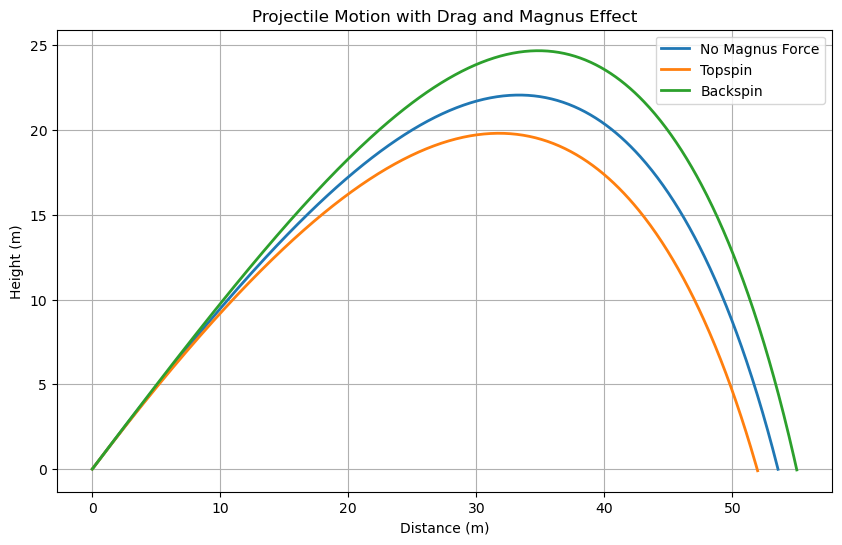

In [4]:
# Simulation Function
def simulate(magnus_type="none"):

    x = [0]
    y = [0]

    vx = vx0
    vy = vy0

    while y[-1] >= 0:

        # Total speed
        v = np.sqrt(vx**2 + vy**2)

    
        # Drag Force
        Fd_x = -0.5 * Cd * rho * A * v * vx
        Fd_y = -0.5 * Cd * rho * A * v * vy

        # Magnus Force - only acts in the vertical
        Fm_y = 0

        if magnus_type == "topspin":
            Fm_y = -0.5 * Cl * rho * A * v**2

        elif magnus_type == "backspin":
            Fm_y = 0.5 * Cl * rho * A * v**2

        # Total Forces
        Fx = Fd_x
        Fy = Fd_y + Fm_y - m * g

        # Accelerations
        ax = Fx / m
        ay = Fy / m

        # Update velocities
        vx += ax * dt
        vy += ay * dt

        # Update positions
        x_new = x[-1] + vx * dt
        y_new = y[-1] + vy * dt

        x.append(x_new)
        y.append(y_new)

    return np.array(x), np.array(y)

# Run Simulations
x_none, y_none = simulate("none")
x_top, y_top = simulate("topspin")
x_back, y_back = simulate("backspin")

# Plot
plt.figure(figsize=(10,6))

plt.plot(x_none, y_none, label="No Magnus Force", linewidth=2)
plt.plot(x_top, y_top, label="Topspin", linewidth=2)
plt.plot(x_back, y_back, label="Backspin", linewidth=2)

plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.title("Projectile Motion with Drag and Magnus Effect")

plt.grid(True)
plt.legend()

plt.show()

### Results and Interpretation

The resulting trajectories demonstrate the influence of the Magnus effect on a ball's projectile motion. The topspin case experiences an additional downward force, causing the ball to descend more rapidly and travel a shorter distance. On the other hand, the backspin case experiences an upward lift force that partially counteracts gravity, allowing the ball to stay in the air longer and travel further in the horizontal direction. The no-spin trajectory falls between these two cases. 

These results agree with the expected physics of spinning porjectiles. Athletes in sports such as soccer, volleyball, tennis, and baseball intentionally apply spin to alter a ball's filght path. Although our model simplifies the true aerodynamics involved, it captures fundamental physics phenomenon relating spin, lift, and projectile motion. This simulation provides a useful demonstration of how computational modeling can be used to investigate real-world phenomena, especially if using equations alone can be difficult to analyze. 

### Extending the Model 

After developing a basic projectile model, Colby and Hannah expanded the simulation to use three-dimensional vectors for position, velocity, and force calculations. While the ball's motion remains mostly in the vertical plane, representing quantities as vectors allows the model to more accurately reflect the physics of a spinning ball and provides a framework tht could easily be extended to full 3D motion. 

Three forces act on the ball throughout its flight:
1. Gravity, continuously accelerating the ball downwards.
2. Air resistance, which opposes the direction of motion and increases with speed. 
3. The Magnus Force, which occurs when a spinning ball moves through the air and creates a pressure difference around its surfaces. 

To simplify this model, the assumptions of constant air density, constant spin rate, and no wind effects, were applied. The ball is also treated as a rigid sphere with a fixed mass and cross-sectional area. These assumptions allow Colby to isolate the influence of spin while keeping the simulation computationally efficient.

In [43]:
#Importing libraries.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#Initial conditions.
Cd = 0.47 #Drag Coefficient
Cs = 0.2 #Spin Coefficient
A = 0.038 #Cross Sectional Area
p = 1.225 #Air Density
m = 0.42 #Mass of the Ball
g = 9.81 #Gravity Constant
v0 = 50 #Initial Magnitude of Velocity
r = np.sqrt(A/np.pi) #Radius of the Ball

w = [0, 0, 50] #Angular Velocity
angle = np.radians(45) #Polar Launch Angle


#Creating time step and time array.
dt = 0.01 #Small Time Step
t = np.arange(0, 10, dt) #Time Array

### Computational Approach: Vector-Based Numerical Simulation

The trajectory function calculates the position of the ball at small time intervals using numerical integration. Rather than solving the equations of motion analytically, the program repeatedly updates the ball's velocity and position based on the net force acting on it. This allows the simulation to continuously incorporate forces like drag and the Magnus effect that are difficult to solve exactly. 

Numpy arrays play an important role in this implementation. Position, velocity, acceleration, and force are all represented by vectors, allowing coding operations to be performed efficiently on entire sets of data. The drag force depends on the current velocity, while the Magnus force is calculated using the vectors cross product between the angular velocity vector and the translational velocity vector. This approach closey mirrors the mathematical form of the physical equations and makes the code easier to extend and maintain. 

Although the ball's motion is modeled in two dimensions, the simulation stoes position, velocity, and force as three-component vectors. This allows us to use Numpy's built-in cross product function when calculating the Magnus force. The z-components remain zero throughout the simulation, so the ball's motion is restricted to the x-y plane while still utilizing the vector-based calculations

In [44]:
#Populates the trajectory of the ball based on established constants. Uses arrays to organize data and calculate everything swiftly.
def trajectory():    
    #Creates an empty 2D array for our velocity and our position of the ball. 3 Rows, each for their own XYZ direction.
    v = np.zeros((3, np.size(t)))
    pos = np.zeros((3, np.size(t)))
    
    #Sets the initial velocities in the arrays based on the polar launch angle.
    v[0][0] = v0*np.cos(angle)
    v[1][0] = v0*np.sin(angle)
    
    #Calculations for general position and velocity arrays. Uses while loop since we only care about the information before the ball hits the ground.
    i = 1
    while (pos[1][i-1] >= 0) and (i < np.size(t)):
        #Creates a temporary current velocity vector with all the velocities at the index i-1.
        v_current = v[:, i-1]
        
        #Calculates the force of drag, magnus, and gravity. The magnus force was hard to find, but this is one of the equations for it.
        f_drag = -0.5 * Cd * p * A * v_current*np.linalg.norm(v_current)
        f_mag = 0.5 * p * A * r * Cs * np.cross(w, v_current)
        f_grav = np.array([0, -m*g, 0])
        
        #Since we genuinely deleted most of our code to reapproach this project from an array standpoint, we can now easily sum the force vectors together.
        f_tot = f_drag + f_mag + f_grav
        a = f_tot / m
        
        #Now we update the current velocity and position arrays based on the information we had from the previous iteration.
        v[0, i] = v[0, i-1] + a[0]*dt
        v[1, i] = v[1, i-1] + a[1]*dt
        v[2, i] = v[2, i-1] + a[2]*dt
        
        pos[0, i] = pos[0, i-1] + v[0, i-1]*dt + 0.5*a[0]*dt**2
        pos[1, i] = pos[1, i-1] + v[1, i-1]*dt + 0.5*a[1]*dt**2
        pos[2, i] = pos[2, i-1] + v[2, i-1]*dt + 0.5*a[2]*dt**2
        
        i += 1
    
    #Return the information we care about to avoid having any issues with temporary variables inside our function.
    return t[:i], pos[:,:i], v[:,:i]

#Using our function to set the new values.
t, pos, v = trajectory()

### Results: Positive Spin (Backspin)

The animation below uses positive angular velocity, which generates an upward Magnus force. This force partially counteracts gravity and allows the ball to remain airborne for a longer period of time. The trajectory reaches a greater maximum height and travels farther before returning to the ground. 

The numerical results support this observation. The ball remained in flight for approximately 4.50 seconds and reached its max height after roughly 1.90 seconds. Because the Magnus force provides additional lift throughout this flight, the projectile experiences a longer hang time than it would under gravity and drag alone. 

These results show how backspin is commonly used in sports to increase flight time and distance. We especially wanted to focus on soccer, but this phenomenon expands to baseball, golf, and even volleyball, where players have intent to spin the ball, manipulating its trajectory. 

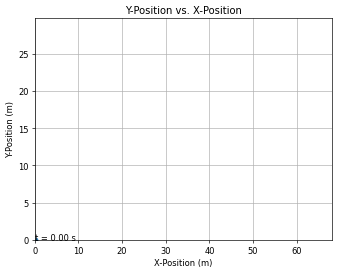

In [45]:
#Animation
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 60
fig, ax = plt.subplots()

def animate(i):
    ax.clear()

    plt.xlabel("X-Position (m)")
    plt.ylabel("Y-Position (m)")
    plt.title("Y-Position vs. X-Position")
    plt.ylim(0, np.max(pos[1])*1.25)
    plt.xlim(0, np.max(pos[0])*1.25)
    plt.grid()
    
    #This type of animation reveals the plot bit by bit instead of recalculating everything, I added the scatter piece to show the ball at that moment, as well as text to attach the time component to the balls trajectory.
    plt.plot(pos[0][:i+1], pos[1][:i+1])
    plt.scatter(pos[0][i], pos[1][i])
    plt.text(pos[0][i], pos[1][i], f"t = {t[i]:.2f} s")
    
anim = FuncAnimation(fig, animate, frames=range(0, len(t), 5))
anim

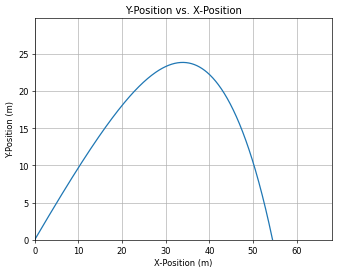

Total Time: 4.5
Time of Max Height: 1.90


In [46]:
#XY-Position graph
plt.close()
plt.figure()
plt.xlabel("X-Position (m)")
plt.ylabel("Y-Position (m)")
plt.title("Y-Position vs. X-Position")
plt.ylim(0, np.max(pos[1])*1.25)
plt.xlim(0, np.max(pos[0])*1.25)
plt.grid()
plt.plot(pos[0], pos[1])
plt.show()

#Printing interesting information.
print(f"Total Time: {np.max(t)}")
print(f"Time of Max Height: {t[np.argmax(pos[1])]:.2f}")

### Results: Negative Spin (Topspin)

To investigate the opposite effect, below, Hannah and Colby reversed the angular velocity to create topspin. In this case, the Magnus force acts downwards, adding to the effect of gravity. As a result, the ball loses altitude more quickly and returns to the ground sooner. 

Compared to the backspin case, the total flight time decreased to approximately 3.90 seconds, and the time required to reach the max height decreased to 1.63 seconds. The trajectory is flatter and shorter as well because the downward Magnus force accelerates the projectile towards the ground. 

This behavior matches observations from many sports. Tennis players often use topspin to make the ball dip rapidly to into the court, while soccer players use topspin to create powerful shots that drop quickly. The simulation successfully reproduces this physical behavior and demonstrates how spin can dramatically alter projectile motion. 

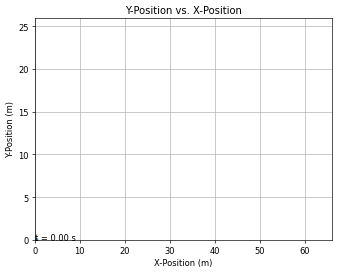

In [38]:
#Changing angular velocity for down spin.
w = [0, 0, -50]
t, pos, v = trajectory()

#Animating
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 60
fig, ax = plt.subplots()

anim = FuncAnimation(fig, animate, frames=range(0, len(t), 5))
anim

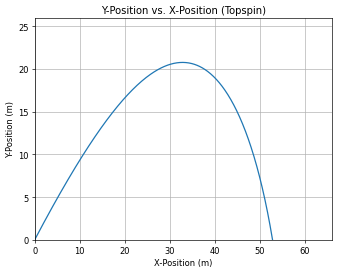

Total Time: 3.9
Time of Max Height: 1.63


In [37]:
#XY-Position graph
plt.close()
plt.figure()
plt.xlabel("X-Position (m)")
plt.ylabel("Y-Position (m)")
plt.title("Y-Position vs. X-Position (Topspin)")
plt.ylim(0, np.max(pos[1])*1.25)
plt.xlim(0, np.max(pos[0])*1.25)
plt.grid()
plt.plot(pos[0], pos[1])
plt.show()

#Printing interesting information.
print(f"Total Time: {np.max(t)}")
print(f"Time of Max Height: {t[np.argmax(pos[1])]:.2f}")

### Conclusion

The computational model successfully demonstrated the impact of the Magnus effect on the flight of a soccer ball. When positive spin was applied, the Magnus force generated lift that increased the ball's flight time and max height. The simulation showed a total flight time of 4.50 seconds and a time to reach max height of 1.90 seconds. 

When the direction of spin was reversed, the Magnus force acted downward, causing the ball to descend more quickly. In this case, total flight time decreased to 3.90 seconds and the time to reach max height was 1.63 seconds. 

These results indicate that spin can significantly alter projectile motion. Backspin tends to keep the ball in the air longer by creating lift, while topspin causes the ball to drop more rapidly by adding a downward force. The model therefore supports the conclusion that the Magnus effect plays an important role in determining the trajectory and flight characteristics of a spinning soccer ball.

### Limitations

Although the model captures the major physical effects involved in a spinning soccer ball's flight, some limitations remain. 

First, the spin rate was assumed to remain constant throughout the flight. In reality, air resistance gradually reduces the ball's angular velocity. Second, the drag coefficient and spin coefficient were treated as constants, even though these values can vary with speed and flow conditions. Third, the simulation ignored wind, weather, and turbulence, all of which can significantly influence a real soccer ball's trajectory. 

Future versions of the model could include changing spin rates, variable aerodynamic coefficients, wind effects, and full 3D motion. These additions would increase realism and allow the simulation to more accurately represent real-world soccer shots. 

##### References

NumPy Documentation:
https://numpy.org/doc/

Encyclopaedia Britannica - Magnus Effect:
https://www.britannica.com/science/Magnus-effect

Wikipedia - Magnus Effect:
https://en.wikipedia.org/wiki/Magnus_effect

University of Oslo Computational Essay Showroom - Fastest Possible Volleyball Serve:
https://uio-ccse.github.io/computational-essay-showroom/essays/exampleessays/volleyball/Volleyball.html

The group also referenced Stack Overflow for portions of code. 